# Re-plot every decoding figure, cleanly

Every decoding job writes a `*_MASTER_RESULTS_*.pkl` next to its figures, holding the pooled
statistics, the significance masks and the run's arguments. That is everything a figure needs,
so this notebook re-draws the figures from those pickles — no decoding is re-run.

What changes versus the figures the jobs wrote:

| | before | after |
|---|---|---|
| title | 3 lines: raw comparison key, ROI, electrode set, n, subjects | `LWPC in congruency-only electrodes` |
| legend | dictionary keys (`i_vs_c_at_inc25`, `lwpc_..._across_bootstraps`) | `25% incongruent`, `75% incongruent`, `Shuffle` |
| trace colours | one colour for both conditions, solid vs dashed | light/dark pair of the same hue, both solid |
| significance | bars dropped on top of the data at a hand-tuned y, stray asterisks | a strip above the data, with a legend |
| vs. chance | not shown on the comparison panel at all | one row per condition, under the contrast bars |

Labels, colours and y-axis names all come from `CONDITION_REGISTRY`, so fixing one there fixes
it everywhere — in this notebook **and** in the figures future jobs write.

In [1]:
import os
import sys

try:
    current_script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_script_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_script_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.decoding.plots.replot import (
    find_master_results,
    load_master_results,
    replot_master_results,
    replot_all,
)
from src.analysis.decoding.plots.accuracies import plot_accuracies_with_multiple_sig_clusters

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

['/hpc/group/coganlab/jz421/GlobalLocal', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python311.zip', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/lib-dynload', '', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages']


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)



Qt5Agg backend not available, using default backend
Qt5Agg backend not available, using default backend


## 1. Find every master results file

Point `FIGS_ROOT` at whatever tree you want swept. It recurses, so the decoding `figs` root
picks up every epochs-root / electrode-selection / condition subdirectory in one go.

In [2]:
# Where the decoding jobs wrote their MASTER_RESULTS pickles.
# run_decoding_dcc.py uses  SAVE_DIR = <dcc_scripts/decoding>/figs/<EPOCHS_ROOT_FILE>
# so the default below is that tree, resolved relative to this notebook.
# Override it with an absolute path to sweep somewhere else.
FIGS_ROOT = os.path.join(current_script_dir, 'figs')

# Where the re-drawn figures go. Nothing is written back into FIGS_ROOT, so the
# originals stay untouched and you can compare old against new.
CLEAN_FIGS = os.path.join(current_script_dir, 'clean_figs')

print(f"searching: {FIGS_ROOT}")
runs = find_master_results(FIGS_ROOT)
print(f"{len(runs)} master results files")
runs[['timestamp', 'condition_label', 'electrode_set_label', 'rois', 'n_electrodes', 'n_subjects']]

searching: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs
133 master results files


,timestamp,condition_label,electrode_set_label,rois,n_electrodes,n_subjects
0,20260422_164013,stimulus_lwpc_block_balanced_conditions,sig,"[lpfc, occ]",NaN,19
1,20260422_164013,stimulus_lwps_block_balanced_conditions,sig,"[lpfc, occ]",NaN,19
2,20260422_164024,stimulus_congruency_by_switch_prop_block_balanced_conditions,sig,"[lpfc, occ]",NaN,19
3,20260422_164024,stimulus_switch_type_by_inc_prop_block_balanced_conditions,sig,"[lpfc, occ]",NaN,19
4,20260426_104320,stimulus_lwpc_block_balanced_conditions,sig,[lpfc],NaN,18
...,...,...,...,...,...,...
128,20260814_044945,stimulus_lwpc_block_balanced_conditions,anova_csv_elecs_anova_switch_type,[lpfc],27.0,24
129,20260814_050813,stimulus_lwps_block_balanced_conditions,anova_csv_elecs_anova_switch_type,[lpfc],27.0,24
130,20260814_074742,stimulus_lwpc_block_balanced_conditions,anova_csv_elecs_anova_switch_type_only,[lpfc],22.0,24
131,20260814_080727,stimulus_lwps_block_balanced_conditions,anova_csv_elecs_anova_switch_type_only,[lpfc],22.0,24


`find_master_results` reads each pickle's metadata, so `condition_label`, `electrode_set_label`
and `rois` are the authoritative values from the run, not guesses off the filename. Anything that
failed to load shows up in the `error` column:

In [3]:
bad = runs[runs.error != '']
if len(bad):
    display(bad[['path', 'error']])
else:
    print('all files loaded cleanly')

all files loaded cleanly


### What is on disk, by analysis and electrode set

In [4]:
runs.groupby(['condition_label', 'electrode_set_label']).size().to_frame('n_runs')

n_runs
condition_label                                              electrode_set_label                           
stimulus_congruency_by_switch_prop_block_balanced_conditions sig                                         23
stimulus_lwpc_block_balanced_conditions                      anova_csv_elecs_anova_both                   8
                                                             anova_csv_elecs_anova_congruency             2
                                                             anova_csv_elecs_anova_congruency_only        2
                                                             anova_csv_elecs_anova_lwpc                  10
                                                             anova_csv_elecs_anova_lwpc_only              2
                                                             anova_csv_elecs_anova_lwps                   8
                                                             anova_csv_elecs_anova_lwps_only              2
                                                             anova_csv_elecs_anova_switch_type            2
                                                             anova_csv_elecs_anova_switch_type_only       2
                                                             sig                                          7
stimulus_lwps_block_balanced_conditions                      anova_csv_elecs_anova_both                   8
                                                             anova_csv_elecs_anova_congruency             2
                                                             anova_csv_elecs_anova_congruency_only        2
                                                             anova_csv_elecs_anova_lwpc                   8
                                                             anova_csv_elecs_anova_lwpc_only              2
                                                             anova_csv_elecs_anova_lwps                   8
                                                             anova_csv_elecs_anova_lwps_only              2
                                                             anova_csv_elecs_anova_switch_type            2
                                                             anova_csv_elecs_anova_switch_type_only       2
                                                             sig                                          7
stimulus_switch_type_by_inc_prop_block_balanced_conditions   sig                                         22

## 2. Re-plot everything

One call. Each run writes into `CLEAN_FIGS/<condition>/<electrode set>/...`, so two electrode
sets of the same analysis never overwrite each other. Failures are caught per run and reported
in the returned frame rather than stopping the sweep.

Per run and ROI this produces:

* the **comparison panel** — both conditions, the pooled shuffle, the contrast bars, and each
  condition's own bar against chance;
* a **true-vs-shuffle panel** per comparison.

In [5]:
report = replot_all(runs[runs.error == ''], CLEAN_FIGS)
report[['n_figures', 'error', 'out_dir']]

[1/133] 20260422_164013_MASTER_RESULTS_19_subs_sig_elecs_LDA_20boots_5splits_5reps_repeat_unit_ev_0.9_stimulus_lwpc_block_balanced_conditions.pkl


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimulus_lwpc_block_balanced_conditions/sig/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_clean.png


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimulus_lwpc_block_balanced_conditions/sig/i_vs_c_at_inc25/lpfc/20260422_164013_true_vs_shuffle_i_vs_c_at_inc25_lpfc_clean.png


...

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimulus_lwpc_block_balanced_conditions/anova_csv_elecs_anova_lwpc/i_vs_c_at_inc25/lpfc/20260812_144312_true_vs_shuffle_i_vs_c_at_inc25_lpfc_clean.png


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimulus_lwpc_block_balanced_conditions/anova_csv_elecs_anova_lwpc/i_vs_c_at_inc75/lpfc/20260812_144312_true_vs_shuffle_i_vs_c_at_inc75_lpfc_clean.png
    → 3 figures in /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimulus_lwpc_block_balanced_conditions/anova_csv_elecs_anova_lwpc

133/133 runs re-plotted


,n_figures,error,out_dir
0,6,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
1,6,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
2,6,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
3,6,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
4,3,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
...,...,...,...
128,3,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
129,3,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
130,3,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...
131,3,,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/stimul...


### Only some of them

`runs` is a plain DataFrame, so filter it however you like before handing it over.

In [6]:
lwpc = runs[runs.condition_label.str.contains('lwpc', case=False)]
replot_all(lwpc, os.path.join(CLEAN_FIGS, 'lwpc_only'))

[1/45] 20260422_164013_MASTER_RESULTS_19_subs_sig_elecs_LDA_20boots_5splits_5reps_repeat_unit_ev_0.9_stimulus_lwpc_block_balanced_conditions.pkl


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_only/stimulus_lwpc_block_balanced_conditions/sig/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_clean.png


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_only/stimulus_lwpc_block_balanced_conditions/sig/i_vs_c_at_inc25/lpfc/20260422_164013_true_vs_shuffle_i_vs_c_at_inc25_lpfc_clean.png


...

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_only/stimulus_lwpc_block_balanced_conditions/anova_csv_elecs_anova_lwpc/i_vs_c_at_inc25/lpfc/20260812_144312_true_vs_shuffle_i_vs_c_at_inc25_lpfc_clean.png


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_only/stimulus_lwpc_block_balanced_conditions/anova_csv_elecs_anova_lwpc/i_vs_c_at_inc75/lpfc/20260812_144312_true_vs_shuffle_i_vs_c_at_inc75_lpfc_clean.png
    → 3 figures in /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_only/stimulus_lwpc_block_balanced_conditions/anova_csv_elecs_anova_lwpc

45/45 runs re-plotted


,path,out_dir,n_figures,error
0,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,6,
1,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
2,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
3,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
4,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
5,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
6,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
7,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
8,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,
9,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/figs/Stimulus_-1....,/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/lwpc_o...,3,


## 3. One figure, to check it before sweeping

`replot_master_results` takes the same keyword arguments and returns the paths it wrote.
Use `return_fig=True` to get the figure back inline instead of saving it.

In [7]:
row = runs[runs.error == ''].iloc[0]
master = load_master_results(row.path)

paths = replot_master_results(
    master,
    save_dir=os.path.join(CLEAN_FIGS, 'preview'),
    rois=['lpfc'],
    include_true_vs_shuffle=False,
)
paths

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/preview/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_clean.png


['/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/preview/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_clean']

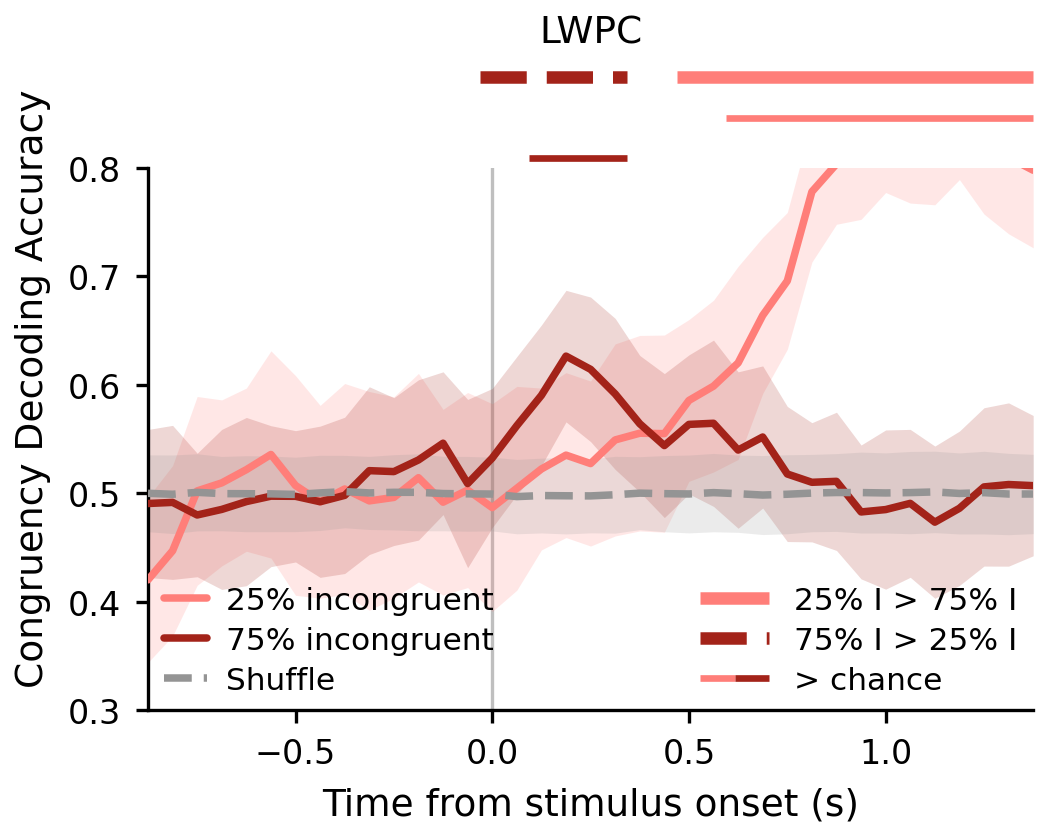

In [8]:
from IPython.display import Image, display

for path in paths:
    display(Image(filename=f'{path}.png'))

## 4. Poster / paper variants

Every knob is a keyword argument, passed straight through to the plotting function.
The ones worth knowing:

| argument | what it does |
|---|---|
| `base_fontsize` | every font size derives from this one number |
| `figsize` | inches; pair a bigger `base_fontsize` with a bigger figure |
| `chance_bar_color` | `None` = each against-chance bar in its trace's colour (default); `'black'` = all neutral |
| `band` | `'std'` (default, what the old figures shaded), `'sem'`, or `None` for no band |
| `ylim` | data range; the significance strip is added *above* it, never over the traces |
| `sig_band_frac` | height of that strip, as a fraction of the axes |
| `legend_loc` / `sig_legend_loc` | move either legend if a trace runs through it |
| `sig_legend_title` | e.g. `'Significance'`; `None` (default) for no heading |
| `formats` | `('png', 'pdf')` by default; add `'eps'` if a journal wants it |

In [9]:
replot_master_results(
    master,
    save_dir=os.path.join(CLEAN_FIGS, 'poster'),
    rois=['lpfc'],
    include_true_vs_shuffle=False,
    base_fontsize=14,
    figsize=(6.5, 5.0),
    ylim=(0.35, 0.8),
    filename_suffix='poster',
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/poster/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_poster.png


['/hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/poster/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_poster']

### Trace-coloured vs black against-chance bars

The thing worth deciding by eye. Trace-coloured bars say *which* condition beats chance;
black bars subordinate them to the contrast bar on top but stop distinguishing the two
conditions — with two rows of identical black bars, only the row order tells you which is which.
Run both and pick.

In [10]:
for name, chance_color in [('trace_colored', None), ('black', 'black')]:
    replot_master_results(
        master,
        save_dir=os.path.join(CLEAN_FIGS, 'chance_bar_styles', name),
        rois=['lpfc'],
        include_true_vs_shuffle=False,
        chance_bar_color=chance_color,
        filename_suffix=name,
    )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/chance_bar_styles/trace_colored/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_trace_colored.png


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved decoding accuracy plot to: /hpc/group/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/clean_figs/chance_bar_styles/black/LWPC_block_balanced_comparison/lpfc/20260422_164013_LWPC_block_balanced_comparison_lpfc_black.png


## 5. Changing the labels and colours

None of the text above is written in this notebook — it all comes from `CONDITION_REGISTRY`,
under each condition set's `context_comparison` block:

```python
'context_comparison': {
    'colors':      {'i_vs_c_at_inc25': '#FF7E79',        # light step = 25%
                    'i_vs_c_at_inc75': '#A32319'},       # dark step  = 75%
    'linestyles':  {'i_vs_c_at_inc25': '-', 'i_vs_c_at_inc75': '-'},
    'ylabel':      'Congruency Decoding Accuracy',
    'display_name': 'LWPC',                              # the title
    'trace_labels': {'i_vs_c_at_inc25': '25% incongruent',
                     'i_vs_c_at_inc75': '75% incongruent'},   # the legend
    'significance_label_1': '25% I > 75% I',             # the contrast bars
    'significance_label_2': '75% I > 25% I',
},
```

Edit there and both this notebook and the figures written by future decoding jobs pick it up.
The colour convention currently in the registry: keep the existing hue as the **light** step for
the 25% level and give the 75% level a **darker companion of the same hue**, both solid. That
frees solid-vs-dashed to mean the *direction of the contrast* on the significance bars.

In [11]:
from src.analysis.config.condition_registry import (
    get_context_comparison_kwargs, get_display_name, get_trace_labels,
)

for label in sorted(runs.condition_label.unique()):
    if not label:
        continue
    cc = get_context_comparison_kwargs(label) or {}
    print(f"{label}")
    print(f"   title       : {get_display_name(label)}")
    print(f"   ylabel      : {cc.get('ylabel', '(none)')}")
    print(f"   trace labels: {get_trace_labels(label)}")
    print(f"   colors      : { {k: v for k, v in cc.get('colors', {}).items() if 'shuffle' not in k} }")

stimulus_congruency_by_switch_prop_block_balanced_conditions
   title       : Congruency by switch proportion
   ylabel      : Congruency Decoding Accuracy
   trace labels: {'i_vs_c_at_sw25': '25% switch', 'i_vs_c_at_sw75': '75% switch'}
   colors      : {'i_vs_c_at_sw25': '#05B0F0', 'i_vs_c_at_sw75': '#0B4F8A'}
stimulus_lwpc_block_balanced_conditions
   title       : LWPC
   ylabel      : Congruency Decoding Accuracy
   trace labels: {'i_vs_c_at_inc25': '25% incongruent', 'i_vs_c_at_inc75': '75% incongruent'}
   colors      : {'i_vs_c_at_inc25': '#FF7E79', 'i_vs_c_at_inc75': '#A32319'}
stimulus_lwps_block_balanced_conditions
   title       : LWPS
   ylabel      : Switch Type Decoding Accuracy
   trace labels: {'s_vs_r_at_sw25': '25% switch', 's_vs_r_at_sw75': '75% switch'}
   colors      : {'s_vs_r_at_sw25': '#05B0F0', 's_vs_r_at_sw75': '#0B4F8A'}
stimulus_switch_type_by_inc_prop_block_balanced_conditions
   title       : Switch type by incongruent proportion
   ylabel      : Switch T

## 6. Hand-built one-offs

For a figure that does not correspond to a stored analysis, call the plotting function directly.
`significance_clusters_dict` entries take `kind='contrast'` (top row) or `kind='chance'`
(one row each, underneath), plus `linestyle` to separate the two directions of a contrast.

In [12]:
context = get_context_comparison_kwargs(row.condition_label)
comp1, comp2 = context['condition_comparison_1'], context['condition_comparison_2']
labels = get_trace_labels(row.condition_label)
unit = master['metadata']['args']['unit_of_analysis']
time_points = master['metadata']['time_window_centers']
roi = 'lpfc'

stats_1 = master['stats'][comp1][roi]
stats_2 = master['stats'][comp2][roi]
clusters = master['comparison_clusters'][roi][context['condition_name'].lower()]
direction_1, direction_2 = list(clusters.values())[:2]

fig = plot_accuracies_with_multiple_sig_clusters(
    time_points=time_points,
    accuracies_dict={
        labels[comp1]: stats_1[f'{unit}_true_accs'],
        labels[comp2]: stats_2[f'{unit}_true_accs'],
    },
    significance_clusters_dict={
        'contrast_1': {'clusters': direction_1['clusters'],
                       'label': context['significance_label_1'],
                       'color': context['colors'][comp1], 'linestyle': '-'},
        'contrast_2': {'clusters': direction_2['clusters'],
                       'label': context['significance_label_2'],
                       'color': context['colors'][comp2], 'linestyle': '--'},
        'chance_1': {'clusters': stats_1['significant_clusters'],
                     'color': context['colors'][comp1], 'kind': 'chance'},
        'chance_2': {'clusters': stats_2['significant_clusters'],
                     'color': context['colors'][comp2], 'kind': 'chance'},
    },
    colors={labels[comp1]: context['colors'][comp1],
            labels[comp2]: context['colors'][comp2]},
    ylabel=context['ylabel'],
    ylim=(0.3, 0.8),
    title=f"{get_display_name(row.condition_label)} — custom",
    show_chance_level=False,
    show_sig_legend=True,
    sig_legend_title='Significance',
    return_fig=True,
)
fig

<Figure size 350.394x280.315 with 1 Axes>